# Seção 01: Execução & Simulação Federada com NVFlare e PyTorch

## 1. Preparação do Ambiente e Verificação de Requisitos


In [2]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import datasets, transforms

import nvflare.client as flare
from nvflare.app_opt.pt.recipes.fedavg import FedAvgRecipe
from nvflare.recipe import SimEnv, add_experiment_tracking

# Princípio III da Constituição: Caminho absoluto para dados
DATA_DIR = os.path.abspath("./data")
os.makedirs(DATA_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo detectado: {device}")
print(f"Diretório absoluto de dados: {DATA_DIR}")

print("Verificando/Baixando conjunto de dados CIFAR-10...")
datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
datasets.CIFAR10(root=DATA_DIR, train=False, download=True)
print("Dados prontos e verificados com sucesso!")


Dispositivo detectado: cpu
Diretório absoluto de dados: /home/julio/documents/github/NVFlare/notebooks/data
Verificando/Baixando conjunto de dados CIFAR-10...
Dados prontos e verificados com sucesso!


## 2. Distribuição dos Clientes

Modelamos a partição Não-IID entre os clientes via amostragem de Dirichlet $(\alpha)$:
- **$\alpha = 100.0$**: Balanceada (IID).
- **$\alpha = 0.5$**: Desbalanceada (Non-IID).


--- Cenário 1: Próximo de IID (alpha = 100.0) ---
=== Tabela de Distribuição dos Clientes (alpha=100.0) ===
Cliente 1: Total = 24954 amostras | Por classe: [np.int64(2625), np.int64(2623), np.int64(2411), np.int64(2380), np.int64(2423), np.int64(2498), np.int64(2764), np.int64(2331), np.int64(2525), np.int64(2374)]
Cliente 2: Total = 25046 amostras | Por classe: [np.int64(2375), np.int64(2377), np.int64(2589), np.int64(2620), np.int64(2577), np.int64(2502), np.int64(2236), np.int64(2669), np.int64(2475), np.int64(2626)]


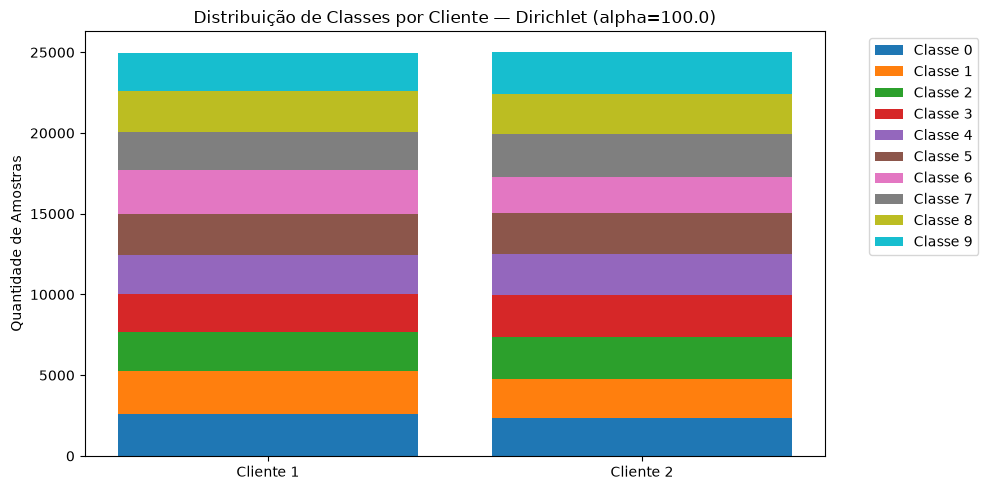

--- Cenário 2: Severe Non-IID (alpha = 0.5) ---
=== Tabela de Distribuição dos Clientes (alpha=0.5) ===
Cliente 1: Total = 21757 amostras | Por classe: [np.int64(541), np.int64(903), np.int64(1660), np.int64(4713), np.int64(3686), np.int64(446), np.int64(1314), np.int64(4956), np.int64(1), np.int64(3537)]
Cliente 2: Total = 28243 amostras | Por classe: [np.int64(4459), np.int64(4097), np.int64(3340), np.int64(287), np.int64(1314), np.int64(4554), np.int64(3686), np.int64(44), np.int64(4999), np.int64(1463)]


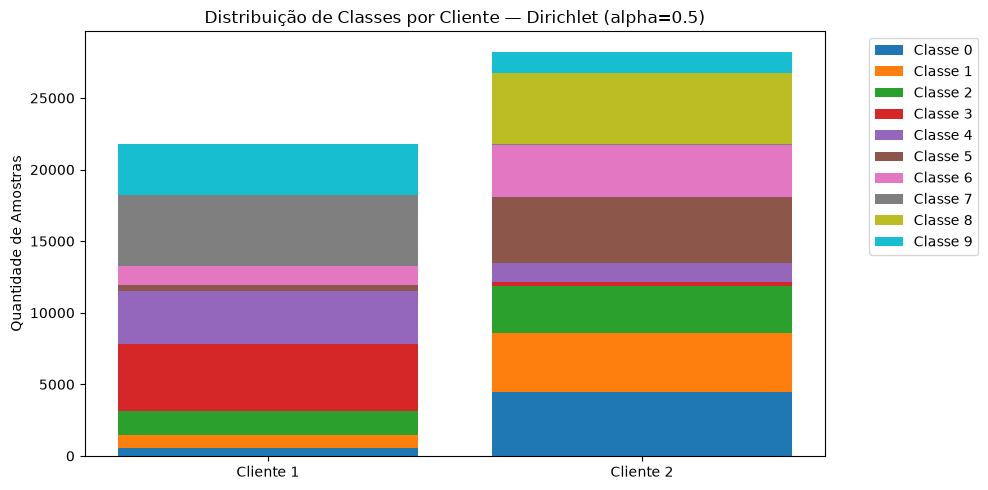

array([[ 541,  903, 1660, 4713, 3686,  446, 1314, 4956,    1, 3537],
       [4459, 4097, 3340,  287, 1314, 4554, 3686,   44, 4999, 1463]])

In [3]:
def plot_dirichlet_distribution(num_clients=2, alpha=100.0, seed=42):
    np.random.seed(seed)
    train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=False)
    labels = np.array(train_dataset.targets)
    num_classes = 10
    
    client_class_counts = np.zeros((num_clients, num_classes), dtype=int)
    
    for k in range(num_classes):
        idx_k = np.where(labels == k)[0]
        np.random.shuffle(idx_k)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = proportions / proportions.sum()
        splits = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
        client_k_indices = np.split(idx_k, splits)
        for client_id in range(num_clients):
            if client_id < len(client_k_indices):
                client_class_counts[client_id, k] = len(client_k_indices[client_id])

    print(f"=== Tabela de Distribuição dos Clientes (alpha={alpha}) ===")
    for client_id in range(num_clients):
        total_samples = client_class_counts[client_id].sum()
        print(f"Cliente {client_id+1}: Total = {total_samples} amostras | Por classe: {list(client_class_counts[client_id])}")

    fig, ax = plt.subplots(figsize=(10, 5))
    classes = [f"Classe {i}" for i in range(10)]
    bottom = np.zeros(num_clients)
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for k in range(num_classes):
        counts = client_class_counts[:, k]
        ax.bar([f"Cliente {i+1}" for i in range(num_clients)], counts, bottom=bottom, label=classes[k], color=colors[k])
        bottom += counts
        
    ax.set_ylabel("Quantidade de Amostras")
    ax.set_title(f"Distribuição de Classes por Cliente — Dirichlet (alpha={alpha})")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return client_class_counts

print("--- Cenário 1: Próximo de IID (alpha = 100.0) ---")
plot_dirichlet_distribution(num_clients=2, alpha=100.0)

print("--- Cenário 2: Severe Non-IID (alpha = 0.5) ---")
plot_dirichlet_distribution(num_clients=2, alpha=0.5)


### Iniciar o Servidor TensorBoard no Terminal

Para visualizar em tempo real todas as curvas de treino interativas, abra o terminal e execute o comando abaixo:

```bash
tensorboard --logdir=/tmp/nvflare/simulation/ --load_fast=false
```

Em seguida, acesse **[http://localhost:6006](http://localhost:6006)** no seu navegador.


In [7]:
# 1. Carrega a extensão do TensorBoard
%load_ext tensorboard

# 2. Inicia o TensorBoard apontando para o seu diretório
%tensorboard --logdir=/tmp/nvflare/simulation/ --load_fast=false

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 48376), started 0:00:24 ago. (Use '!kill 48376' to kill it.)

In [8]:
!rm -rf /tmp/nvflare/simulation/*